## Part 2 — Training a Convolutional Denoiser

Objective: train a compact convolutional network that maps a noisy image to a clean one.

1. Convert `image.png` to `Float32` tensors
2. Synthesize training pairs: clean patches with Gaussian white noise and random-valued impulse noise
3. Define a baseline encoder–decoder (autoencoder) and a compact residual CNN (DnCNN-style)
4. Train both with Zygote and Adam, then compare them
5. Save the trained weights for Part 3

Resource budget: the main model has about 27k parameters (107 KiB) and trains on 40×40 patches. Training needs a few hundred MB of RAM and about two minutes on a CPU.

In [1]:
using Pkg; Pkg.activate("."); Pkg.instantiate()

using Flux, Images, FileIO, Random, Statistics, Plots, JLD2
Random.seed!(42)
println("Julia threads: ", Threads.nthreads())

  Activating 

project at `~/ws_julia/Eco-workshop-n8`


Julia threads: 1

> **Performance note:** conv layers use multiple threads when available. Start Jupyter with `JULIA_NUM_THREADS=auto`, or register a threaded kernel once with
> `using IJulia; IJulia.installkernel("Julia (threads)", "--project=@."; env=Dict("JULIA_NUM_THREADS"=>"auto"))`.

### 1. Data preparation

#### 1.1 Load the image

size = (

539, 600), eltype = RGB{

N0f8}, Float32 RGB = 3.701 MiB


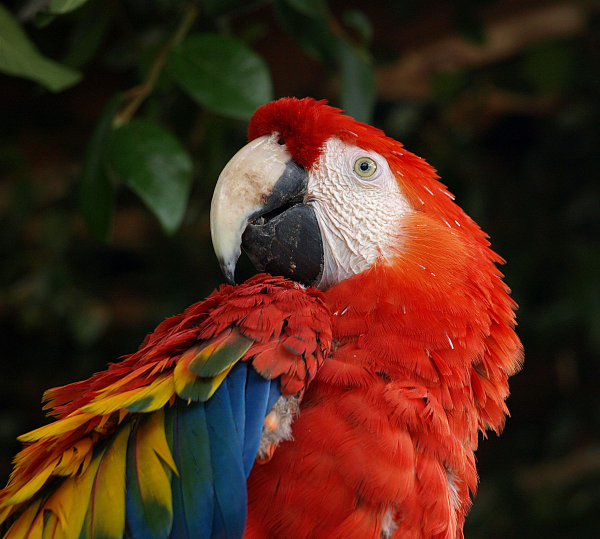

In [2]:
img = load("image.png")
println("size = ", size(img), ", eltype = ", eltype(img),
        ", Float32 RGB = ", Base.format_bytes(3 * length(img) * sizeof(Float32)))
img

A single 24-channel activation of the full image takes `539 × 600 × 24 × 4 B ≈ 31 MB`, and backpropagation keeps every activation of all 7 layers for every image in the batch; a batch of 32 full images would need more than 10 GB. Training therefore uses **small random patches**. The network has no dense layers, so it still applies to images of any size at inference time.

#### 1.2 Image ↔ tensor conversion
`Images.jl` stores an image as an `H × W` matrix of `RGB` values. Flux expects a numeric `H × W × C × N` array.

In [3]:
img_to_tensor(img) = permutedims(Float32.(channelview(RGB{Float32}.(img))), (2, 3, 1))   # H×W×3
tensor_to_img(x)   = colorview(RGB, permutedims(clamp.(x, 0f0, 1f0), (3, 1, 2)))

X = img_to_tensor(img)
size(X), eltype(X), extrema(X)

((539, 600, 3), Float32, (0.0f0, 1.0f0))

#### 1.3 Train/validation split
The top 80 % of the image is used for training and the bottom 20 % is held out for validation, so the model is always evaluated on pixels it has never seen.

In [4]:
n_train = floor(Int, 0.8 * size(X, 1))     # rows used for training
X_train = X[1:n_train, :, :]
X_val   = X[n_train+1:end, :, :]
size(X_train), size(X_val)

((431, 600, 3), (108, 600, 3))

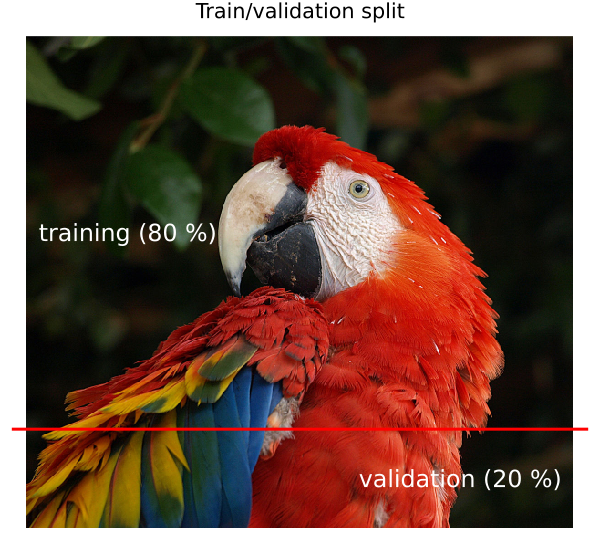

In [5]:
plot(img; axis=false, ticks=false, size=(600, 540), title="Train/validation split")
hline!([n_train]; color=:red, lw=3, label="")
annotate!(15, n_train / 2, text("training (80 %)", :white, 16, :left))
annotate!(585, (n_train + size(img, 1)) / 2, text("validation (20 %)", :white, 16, :right))

### 2. Data synthesis

#### 2.1 Patch sampling with augmentation
Random crops, flips and transposes give a practically unlimited stream of distinct training examples.

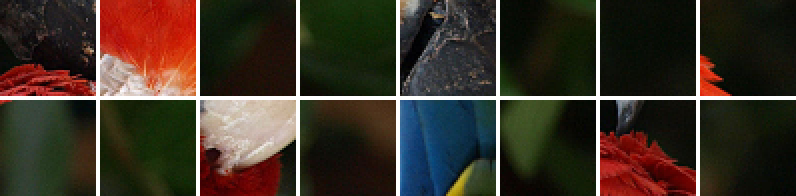

In [6]:
PATCH = 40

function sample_patches(X, n; p=PATCH, rng=Random.default_rng())
    out = Array{Float32}(undef, p, p, 3, n)            # WHCN
    for k in 1:n
        i = rand(rng, 1:size(X, 1) - p + 1)
        j = rand(rng, 1:size(X, 2) - p + 1)
        P = X[i:i+p-1, j:j+p-1, :]
        rand(rng, Bool) && (P = reverse(P; dims=1))
        rand(rng, Bool) && (P = reverse(P; dims=2))
        rand(rng, Bool) && (P = permutedims(P, (2, 1, 3)))
        out[:, :, :, k] .= P
    end
    return out
end

# Tile a batch into one image; nearest-neighbour zoom for display
function show_batch(x; nrow=2, zoom=2)
    tiles = [tensor_to_img(x[:, :, :, k]) for k in axes(x, 4)]
    return repeat(mosaicview(tiles; nrow, npad=2, fillvalue=RGB{Float32}(1, 1, 1)); inner=(zoom, zoom))
end

clean_demo = sample_patches(X_train, 16; p=48)
show_batch(clean_demo)

#### 2.2 Noise models
The noise is generated in code, so the clean target is always known. The noise levels are deliberately strong, so the degradation is clearly visible.

| Noise | Definition | Visual effect |
|---|---|---|
| Gaussian white noise | $\tilde{x} = \mathrm{clip}(x + \sigma\varepsilon),\ \varepsilon\sim\mathcal N(0,1)$, independent per pixel and channel | grain over the whole image |
| Random-valued impulse noise | each pixel is replaced with probability *p* by a uniformly random colour | isolated coloured specks |
| Training mixture | σ ~ U[0.05, 0.35] per image, plus impulse noise with p ~ U[0, 0.20] on half of the images | both |

Metric: $\mathrm{PSNR} = 10\log_{10}(1/\mathrm{MSE})$ in dB, for images in [0, 1]. Higher is better.

In [7]:
per_image(v, x) = reshape(v, 1, 1, 1, size(x, 4))      # one value per image in the batch

add_gaussian_noise(x, σ; rng=Random.default_rng()) =
    clamp.(x .+ Float32.(σ) .* randn(rng, Float32, size(x)), 0f0, 1f0)

function add_impulse_noise(x, p; rng=Random.default_rng())
    hit = rand(rng, Float32, size(x, 1), size(x, 2), 1, size(x, 4)) .< p   # same pixels in all channels
    return ifelse.(hit, rand(rng, Float32, size(x)), x)                     # replaced by a random colour
end

function add_training_noise(x; σ=(0.05f0, 0.35f0), p=(0f0, 0.20f0), rng=Random.default_rng())
    n  = size(x, 4)
    σs = per_image(σ[1] .+ (σ[2] - σ[1]) .* rand(rng, Float32, n), x)
    ps = per_image(ifelse.(rand(rng, n) .< 0.5f0, p[1] .+ (p[2] - p[1]) .* rand(rng, Float32, n), 0f0), x)
    return add_impulse_noise(add_gaussian_noise(x, σs; rng), ps; rng)
end

psnr(x, ref) = 10 * log10(1 / mean(abs2, x .- ref))

psnr (generic function with 1 method)

Gaussian σ = 0.15     PSNR = 

17.93 dB
Gaussian σ = 0.30     PSNR = 12.75 dB
impulse p = 0.15      PSNR = 14.65 dB
σ = 0.15 + p = 0.10   PSNR = 14.4 dB


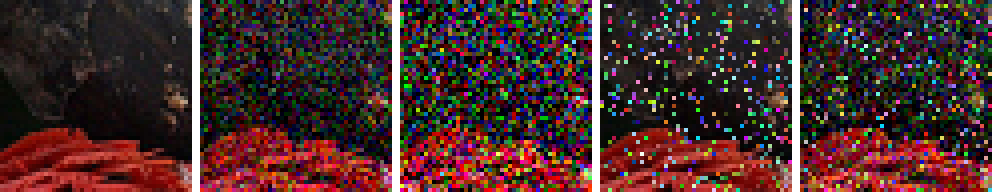

In [8]:
patch = clean_demo[:, :, :, 1:1]
variants = [("clean", patch),
            ("Gaussian σ = 0.15", add_gaussian_noise(patch, 0.15)),
            ("Gaussian σ = 0.30", add_gaussian_noise(patch, 0.30)),
            ("impulse p = 0.15", add_impulse_noise(patch, 0.15)),
            ("σ = 0.15 + p = 0.10", add_impulse_noise(add_gaussian_noise(patch, 0.15), 0.10))]
for (name, v) in variants[2:end]
    println(rpad(name, 22), "PSNR = ", round(psnr(v, patch); digits=2), " dB")
end
show_batch(cat(last.(variants)...; dims=4); nrow=1, zoom=4)

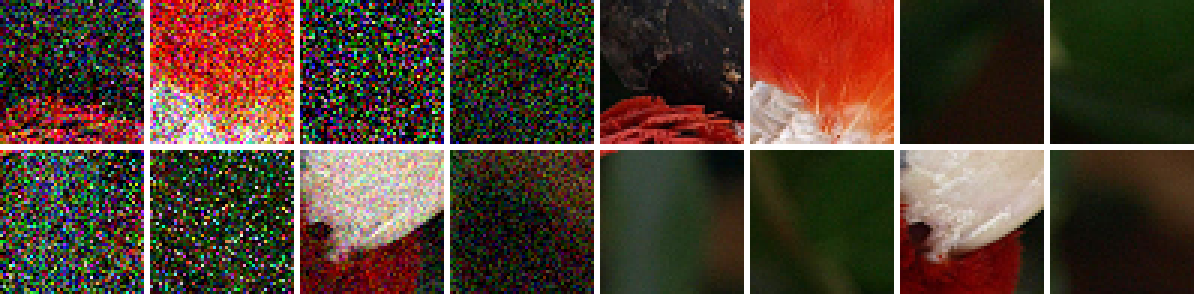

In [9]:
# Training pairs: noisy inputs (top), clean targets (bottom)
noisy_demo = add_training_noise(clean_demo)
show_batch(cat(noisy_demo[:, :, :, 1:8], clean_demo[:, :, :, 1:8]; dims=4); nrow=2, zoom=3)

#### 2.3 Fixed validation set
128 validation patches of 48×48 with mixed noise (σ = 0.15, p = 0.10). The noise uses seeded RNGs, so the results are reproducible.

In [10]:
clean_val = sample_patches(X_val, 128; p=48, rng=Xoshiro(7))
noisy_val = add_impulse_noise(add_gaussian_noise(clean_val, 0.15; rng=Xoshiro(8)), 0.10; rng=Xoshiro(9))
println("Noisy validation PSNR (baseline): ", round(psnr(noisy_val, clean_val); digits=2), " dB")

Noisy validation PSNR (baseline): 14.43

 dB


### 3. Architecture

#### 3.1 Baseline: convolutional autoencoder (encoder–decoder)
```
noisy  H×W×3
  Conv 3×3        3→16             H   × W   × 16
  Conv 3×3 s2     16→32            H/2 × W/2 × 32
  Conv 3×3 s2     32→32            H/4 × W/4 × 32    bottleneck
  ConvT 4×4 s2    32→32            H/2 × W/2 × 32
  ConvT 4×4 s2    32→16            H   × W   × 16
  Conv 3×3        16→3, sigmoid    H   × W   × 3
```
The bottleneck discards noise, which is hard to compress, but it also discards fine detail. Expect smooth, blurred output.

In [11]:
function build_autoencoder(; c=16)
    encoder = Chain(
        Conv((3, 3), 3 => c, relu; pad=1),
        Conv((3, 3), c => 2c, relu; pad=1, stride=2),            # ↓ 1/2
        Conv((3, 3), 2c => 2c, relu; pad=1, stride=2),           # ↓ 1/4
    )
    decoder = Chain(
        ConvTranspose((4, 4), 2c => 2c, relu; pad=1, stride=2),  # ↑ 1/2
        ConvTranspose((4, 4), 2c => c, relu; pad=1, stride=2),   # ↑ 1
        Conv((3, 3), c => 3, sigmoid; pad=1),
    )
    return Chain(; encoder, decoder)                              # named Chain
end

autoencoder = build_autoencoder()
println("bottleneck: ", Flux.outputsize(autoencoder.layers.encoder, (48, 48, 3, 1)))
println("output:     ", Flux.outputsize(autoencoder, (48, 48, 3, 1)))
println("parameters: ", sum(length, Flux.trainables(autoencoder)))

bottleneck: (

12, 12, 32, 1)
output:     (

48, 48, 3, 1)
parameters: 39395

#### 3.2 Compact residual CNN (DnCNN-style)
Based on DnCNN (Zhang et al., 2017), reduced to 7 layers and 24 channels:
1. **No downsampling:** every layer works at full resolution, so there is no bottleneck and fine detail is kept.
2. **Residual learning:** the network estimates the noise n̂, and the output is `x − n̂`. Estimating the noise is easier than reconstructing the whole image. In Flux: `SkipConnection(noise_estimator, subtract_noise)`.
3. **Receptive field:** 7 stacked 3×3 convolutions see a 15×15 neighbourhood per output pixel, which is enough context for pixel-level noise.

```
x ───────────────────────────────────────┐
  Conv 3×3  3→24, ReLU                   │
  5 × [Conv 3×3  24→24, ReLU]            │ residual
  Conv 3×3  24→3          = n̂            │
  x − n̂ ◄────────────────────────────────┘
```
The combine function is named rather than anonymous, so Part 3 can rebuild the same model.

In [12]:
subtract_noise(noise, x) = x .- noise

function build_denoiser(; c=24, depth=7)
    noise_estimator = Chain(
        Conv((3, 3), 3 => c, relu; pad=1),                             # feature extraction
        [Conv((3, 3), c => c, relu; pad=1) for _ in 1:depth-2]...,     # feature processing
        Conv((3, 3), c => 3; pad=1),                                   # noise estimate
    )
    return SkipConnection(noise_estimator, subtract_noise)
end

denoiser = build_denoiser()

SkipConnection(
  Chain(
    Conv((3, 3), 3 => 24, relu, pad=1),  # 672 parameters
    Conv((3, 3), 24 => 24, relu, pad=1),  # 5_208 parameters
    Conv((3, 3), 24 => 24, relu, pad=1),  # 5_208 parameters
    Conv((3, 3), 24 => 24, relu, pad=1),  # 5_208 parameters
    Conv((3, 3), 24 => 24, relu, pad=1),  # 5_208 parameters
    Conv((3, 3), 24 => 24, relu, pad=1),  # 5_208 parameters
    Conv((3, 3), 24 => 3, pad=1),       # 651 parameters
  ),
  Main.subtract_noise,
)                   # Total: 14 arrays, 27_363 parameters, 108.254 KiB.

In [13]:
println("output:          ", Flux.outputsize(denoiser, (48, 48, 3, 1)))
println("parameters:      ", sum(length, Flux.trainables(denoiser)))
println("weights:         ", Base.format_bytes(sum(sizeof, Flux.trainables(denoiser))))
rf = 2 * length(denoiser.layers) + 1              # each 3×3 conv adds 2 pixels
println("receptive field: ", rf, "×", rf, " pixels")

output:          (

48, 48, 3, 1)
parameters:      27363
weights:         106.887 KiB
receptive field: 15×15 pixels


### 4. Training
Each epoch:
1. Synthesizes new patches and new noise
2. Batches them with `DataLoader`
3. Computes the loss and gradients with `Flux.withgradient` (Zygote) and applies an Adam step with `Flux.update!`

The learning rate is reduced by a factor of 5 for the final quarter of training (`Flux.adjust!`). Loss: `Flux.mse`.

In [14]:
function train_model!(model; epochs=10, patches_per_epoch=1024, batchsize=32, lr=2f-3, name="model")
    opt_state = Flux.setup(Adam(lr), model)
    history = (train_loss = Float32[], val_psnr = Float32[])

    for epoch in 1:epochs
        epoch == round(Int, 0.75epochs) && Flux.adjust!(opt_state, lr / 5)

        t = @elapsed begin
            clean  = sample_patches(X_train, patches_per_epoch)
            noisy  = add_training_noise(clean)
            loader = Flux.DataLoader((noisy, clean); batchsize, shuffle=true)
            total = 0f0
            for (xb, yb) in loader
                loss, grads = Flux.withgradient(m -> Flux.mse(m(xb), yb), model)
                Flux.update!(opt_state, model, grads[1])
                total += loss
            end
        end

        push!(history.train_loss, total / length(loader))
        push!(history.val_psnr, psnr(clamp.(model(noisy_val), 0f0, 1f0), clean_val))
        if epoch == 1 || epoch % 5 == 0
            println(rpad(name, 12), "epoch ", lpad(epoch, 3),
                    " │ loss ", round(history.train_loss[end]; sigdigits=3),
                    " │ val PSNR ", round(history.val_psnr[end]; digits=2), " dB",
                    " │ ", round(t; digits=1), " s", epoch == 1 ? " (incl. compilation)" : "")
        end
    end
    return history
end

train_model! (generic function with 1 method)

#### 4.1 Baseline autoencoder
Takes about 30 seconds on one thread. Set `TRAIN_BASELINE = false` to skip it.

In [15]:
TRAIN_BASELINE = true
EPOCHS = 10

if TRAIN_BASELINE
    Random.seed!(1)
    autoencoder = build_autoencoder()
    hist_ae = @time train_model!(autoencoder; epochs=EPOCHS, name="autoencoder")
end;

autoencoder epoch 

  1 │ loss 0.0945 │ val PSNR 14.1 dB │ 16.3 s (incl. compilation)
autoencoder 

epoch   5 │ loss 0.00899 │ val PSNR 20.82 dB │ 2.0 s
autoencoder 

epoch  10 │ loss 0.0041 │ val PSNR 22.32 dB │ 2.0 s
 37.322542 seconds (74.52 M allocations: 18.647 GiB, 8.82% gc time, 43.39% compilation time)


#### 4.2 Residual CNN denoiser
Takes about 1.5 minutes on one thread.

In [16]:
Random.seed!(1)
denoiser = build_denoiser()
hist_dn = @time train_model!(denoiser; epochs=EPOCHS, name="denoiser");

denoiser    epoch 

  1 │ loss 0.0291 │ val PSNR 18.66 dB │ 9.3 s (incl. compilation)
denoiser    

epoch   5 │ loss 0.00605 │ val PSNR 23.71 dB │ 7.3 s
denoiser    

epoch  10 │ loss 0.0042 │ val PSNR 24.24 dB │ 8.5 s
 80.302124 seconds (6.50 M allocations: 40.626 GiB, 11.86% gc time, 3.13% compilation time)


#### 4.3 Learning curves

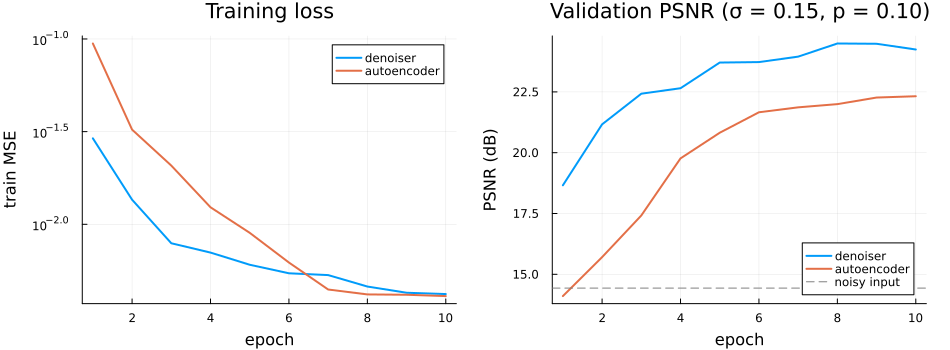

In [17]:
p1 = plot(hist_dn.train_loss; yscale=:log10, lw=2, label="denoiser", xlabel="epoch", ylabel="train MSE", title="Training loss")
p2 = plot(hist_dn.val_psnr; lw=2, label="denoiser", xlabel="epoch", ylabel="PSNR (dB)",
          title="Validation PSNR (σ = 0.15, p = 0.10)", legend=:bottomright)
if TRAIN_BASELINE
    plot!(p1, hist_ae.train_loss; lw=2, label="autoencoder")
    plot!(p2, hist_ae.val_psnr; lw=2, label="autoencoder")
end
hline!(p2, [psnr(noisy_val, clean_val)]; ls=:dash, color=:gray, label="noisy input")
plot(p1, p2; layout=(1, 2), size=(950, 350), margin=4Plots.mm)

### 5. Evaluation on validation patches
Rows, top to bottom: noisy input, autoencoder, residual CNN, ground truth.

noisy       14.35 dB
autoencoder 23.13 dB
denoiser    24.17 dB


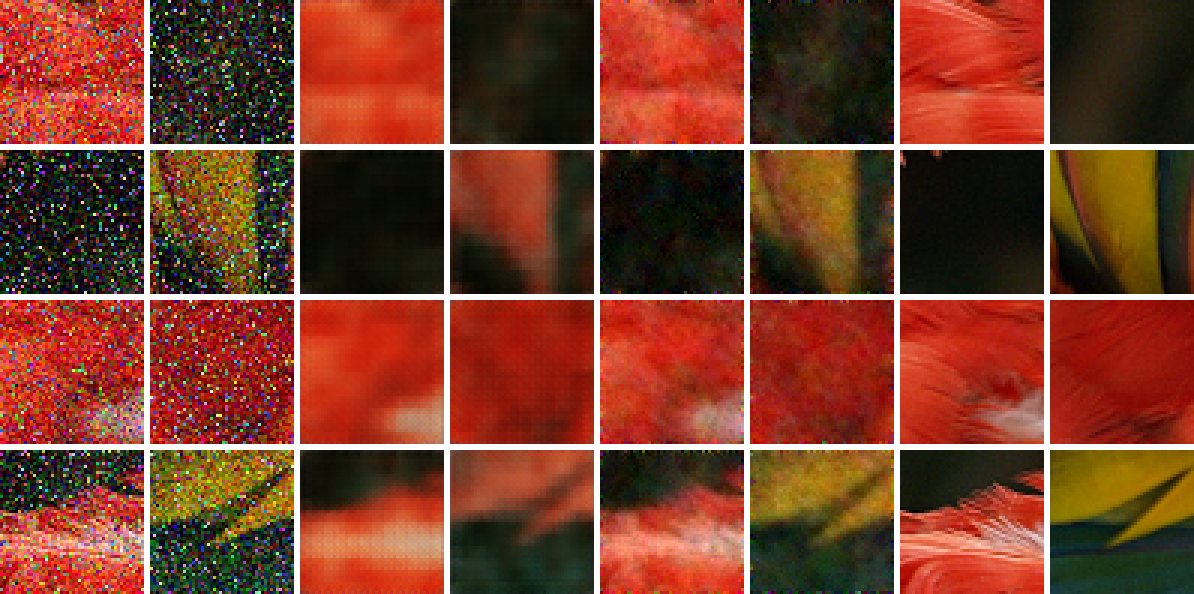

In [18]:
idx  = 1:8
x_in = noisy_val[:, :, :, idx]
ref  = clean_val[:, :, :, idx]
outs = TRAIN_BASELINE ? ["noisy" => x_in, "autoencoder" => autoencoder(x_in), "denoiser" => denoiser(x_in)] :
                        ["noisy" => x_in, "denoiser" => denoiser(x_in)]

for (name, r) in outs
    println(rpad(name, 12), round(psnr(clamp.(r, 0f0, 1f0), ref); digits=2), " dB")
end
show_batch(cat(last.(outs)..., ref; dims=4); nrow=length(outs) + 1, zoom=3)

#### 5.1 First-layer feature maps
The 24 channels of the first convolution respond to colour, edges and noise.

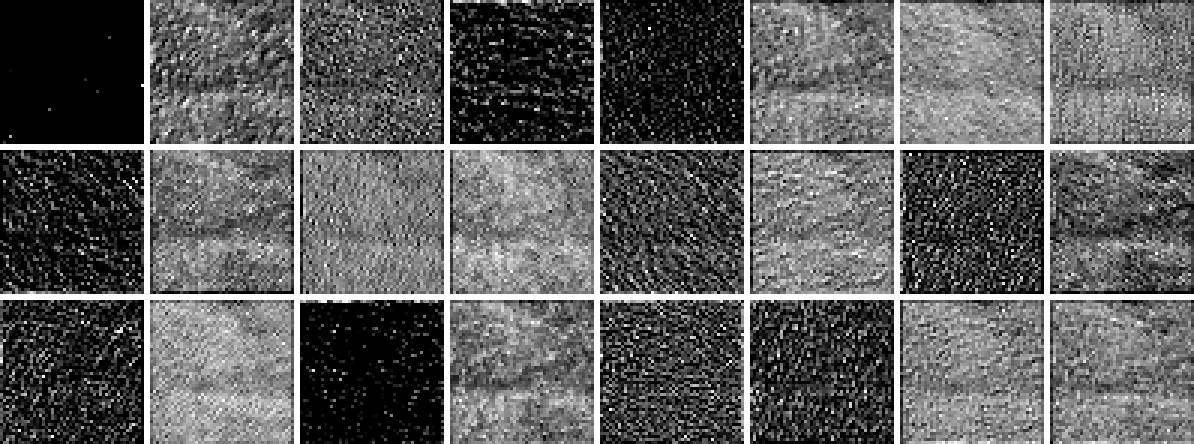

In [19]:
first_conv = denoiser.layers.layers[1]          # SkipConnection → Chain → Conv
fmaps = first_conv(noisy_val[:, :, :, 1:1])      # 48×48×24×1

normalise(a) = (a .- minimum(a)) ./ (maximum(a) - minimum(a) + eps(Float32))
tiles = [Gray.(normalise(fmaps[:, :, k, 1])) for k in axes(fmaps, 3)]
repeat(mosaicview(tiles; nrow=3, npad=2, fillvalue=Gray(1f0)); inner=(3, 3))

### 6. Save the model
The file stores the weights (`Flux.state`), the configuration needed to rebuild the architecture, and the training history.

In [20]:
config = (c = 24, depth = 7, patch = PATCH, σ_train = (0.05, 0.35), p_train = (0.0, 0.20), epochs = EPOCHS)
jldsave("denoiser.jld2"; model_state = Flux.state(denoiser), config, history = hist_dn)
println("saved denoiser.jld2 (", Base.format_bytes(filesize("denoiser.jld2")), ")")

saved denoiser.jld2 (132.271 KiB

)


### Summary

| Step | Tool |
|---|---|
| Tensor conversion | `channelview`, `permutedims` → WHCN `Float32` |
| Data synthesis | random crops and flips; Gaussian and impulse noise, regenerated every epoch |
| Architecture | `Conv`, `ConvTranspose`, named `Chain`, `SkipConnection` |
| Optimisation | `Flux.withgradient`, `Flux.setup`, `Flux.update!`, `Flux.adjust!` |
| Persistence | `Flux.state`, `jldsave` |

**Exercises**
- Change the width `c` (16, 24 or 32) and the `depth`, then compare parameter count, training time and PSNR.
- Add a residual connection to the autoencoder (`SkipConnection(..., subtract_noise)`) and measure the gain.
- Train with Enzyme: `Flux.withgradient(f, Duplicated(model))` after `using Enzyme`.

Next: **03_denoise_inference.ipynb**